In [1]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 23.35it/s]


Numba compilation complete!


In [2]:
#initial file processing
homecomp = "D:"
leif = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\2024 Capstone project\\Data Compilation\\Compiled Data\\"
titledpath = homecomp
openPath = titledpath + leif
files2 = os.listdir(openPath)

## Functions

In [21]:
def pergenotypeplotting(openPath, files2, k): 
    # input is a metric name
    metricname = pd.DataFrame()
    singlemeandiff= pd.DataFrame()
    
    for f in files2:
        samplefile = pd.DataFrame()
        singlemeans = pd.DataFrame()
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "")
        samplefile['bootstrap'] = newfile2read[k+"_bootstrap"]
        samplefile['deltag'] = newfile2read[k+"_deltag"]
        samplefile['Cross'] = cross.replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "")
        samplefile["metric"] = k
        
        singlemeans['mean'] = samplefile['deltag'].unique()
        singlemeans['cross'] = cross.replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "")
        singlemeans['err'] =  samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))  #mean -bca_low (self calculated)

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

def forestplot(metricname, singlemeandiff):
    g = sns.FacetGrid(metricname, row='Cross', aspect = 15,
                    height=0.4)
        
    g.map(sns.kdeplot, 'bootstrap', color="g",
        bw_adjust=1, clip_on=False, clip = (-3,1.5),  
        fill=True, alpha=0.3, linewidth=0, warn_singular=False) # 'color' will change the shaded violin plot and 'clip' changes the range of the x axis numbers. make sure they match with the plt.xticks below

    g.map(plt.axhline, y=0, color="k",
        lw=0.5, clip_on=False)

    g.map(plt.axvline, x=0,
        lw=0.5, clip_on=False, color="k")

    # colors = [["#FFD6EE", "#FFD6EE"], ["#FFD6EE", "#FFD6EE"], #rosepink
    #           ['#DBF3FF', '#DBF3FF'], ['#DBF3FF', '#DBF3FF'], #pastelblue
    #           ["#F3F5A9", "#F3F5A9"], ["#F3F5A9", "#F3F5A9"]   #yellow
              
    #           ]   
    #["#CDE5D9", "#CDE5D9"], ["#CDE5D9", "#CDE5D9"] #pastel green
    
    # colors = [ ["#FFD6EE", "#FFD6EE"],
    #         ['#DBF3FF', '#DBF3FF'],  #pastelblue
    #         ["#F3F5A9", "#F3F5A9"],    #yellow
           
    #         ]   
    
    colors = [ ["w", "w"],   ['w', 'w'],  ["w", "w"]]
    
    colors = [ ["#F3F5A9", "#F3F5A9"],["#F3F5A9", "#F3F5A9"],
            ["#cbceee", "#cbceee"],  ["#cbceee", "#cbceee"]

            ]   

    #for mean line and dots
    for ax, mean, err, cat, colo in zip(g.axes.flat, 
                                singlemeandiff["mean"], 
                                singlemeandiff['err'],
                                singlemeandiff['cross'],
                                colors):
        ax.errorbar(x=mean, y=0, xerr = err, fmt='o',
                    ecolor="k", elinewidth = 2,
                **{"mfc" : "k", "mec" : "k", "markersize" : 3})
        ax.set_ylim(-2,2)  #height of bar
        cell_text = cat.split(",")
        cell_text.append("{:+.2f}".format(mean))
        
        table = ax.table(cellText=[cell_text],loc="left", cellColours = [colo] )
        cellDict = table.get_celld()
        for i in range(0,2):
            cellDict[(0,i)].set_height(1.2)
            cellDict[(0,0)].set_width(0.4)
            cellDict[(0,1)].set_width(0.1)
            
    # cellDict[(0, 0)].set_facecolor('lightblue')  # Row 1, Col 1
    # cellDict[(0, 1)].set_facecolor('lightgreen')  # Row 1, Col 2
    # cellDict[(0, 2)].set_facecolor('lightblue')    
    
    
    
    g.set_titles("")
    g.set(yticks=[])

    plt.xticks(np.arange(-3.5, 2.0, 0.5).tolist(), fontsize = 6)   #change the x- tick labels here
    g.set_ylabels("")
    g.set_xlabels("Δ of " + metricname['metric'].unique()[0], labelpad = 10 )
    g.despine(bottom=True, left=True)

    return g


## Code

In [4]:
files2 = os.listdir(openPath)
files2

['46146jus x ACR[ATR] allstats.csv',
 '46146jus x eOPN3 allstats.csv',
 '46146jus x eOPN3[ATR] allstats.csv',
 'Cha x eOPN3 allstats.csv',
 'Cha x PdCO allstats.csv',
 'elav x ACR allstats.csv',
 'elav x eOPN3 allstats.csv',
 'nsyb x ACR allstats.csv',
 'nsyb x eOPN3 allstats.csv',
 'nsyb x PdCO [B] allstats.csv',
 'OK371 x ACR allstats.csv',
 'OK371 x eOPN3 allstats.csv',
 'OK371 x eOPN3-galphai allstats.csv',
 'OK371 x eOPN3-galphao allstats.csv',
 'OK371 x PdCO allstats.csv',
 'OK371 x PdCO [B] allstats.csv',
 'Piezo x ACR allstats.csv',
 'Piezo x eOPN3 allstats.csv',
 'Piezo x eOPN3-galphai allstats.csv',
 'Piezo x eOPN3-galphao allstats.csv',
 'Piezo x PdCO allstats.csv',
 'Piezo x PdCO [B] allstats.csv',
 'Repo x ACR allstats.csv',
 'Repo x eOPN3 allstats.csv',
 'vGAT x eOPN3 allstats.csv']

In [18]:
## uncomment whichever set you want to look at, do not uncomment everything

# files3 = ['46146jus x ACR[ATR] allstats.csv',
#  '46146jus x eOPN3 allstats.csv',
#  '46146jus x eOPN3[ATR] allstats.csv',
#  'elav x ACR allstats.csv',
#  'elav x eOPN3 allstats.csv',
#   'OK371 x ACR allstats.csv',
#  'OK371 x eOPN3 allstats.csv',
# ]

# files3 = ['Cha x eOPN3 allstats.csv',
#  'vGAT x eOPN3 allstats.csv', 
# 'nsyb x eOPN3 allstats.csv'
# ]

# files3 = ['OK371 x ACR allstats.csv',
#  'OK371 x eOPN3 allstats.csv',
#  'OK371 x eOPN3-galphai allstats.csv',
#  'OK371 x eOPN3-galphao allstats.csv'
#  ]



# files3 = ['Piezo x ACR allstats.csv',
#  'Piezo x eOPN3 allstats.csv',
#  'Piezo x eOPN3-galphai allstats.csv',
#  'Piezo x eOPN3-galphao allstats.csv']



files3 = ['nsyb x eOPN3 allstats.csv',
 'nsyb x PdCO [B] allstats.csv',
  'Cha x eOPN3 allstats.csv',
 'Cha x PdCO allstats.csv',]

In [19]:
lstnamings = ['fallprop', 'speed', 'height']  #dont change this

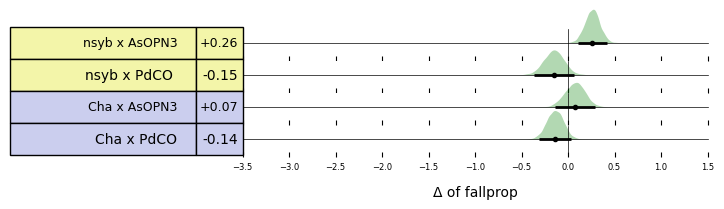

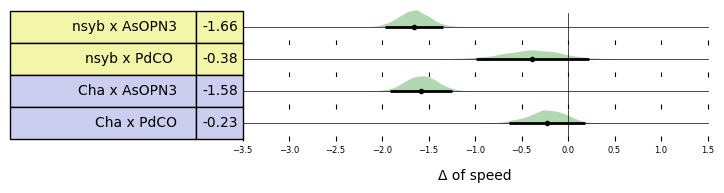

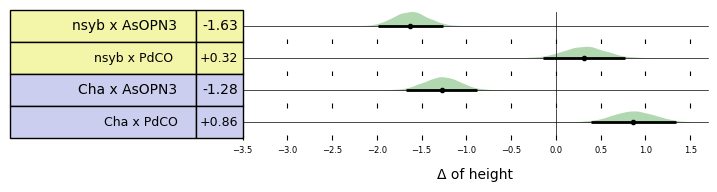

In [22]:
for n in lstnamings:
    dfmn, dfsmd = pergenotypeplotting(openPath, files3, n)
    g = forestplot(dfmn, dfsmd)
    #g.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\2024 Capstone project\\Data Compilation\\images\\forestplot of OK371galpha_" + n, dpi=300, bbox_inches="tight")   #change this filename where appropriate